#🗃️  Bibliotecas

In [1]:
import pandas as pd                     # Análise e Leitura
import plotnine as p9                   # Gráficos
import statsmodels.formula.api as smf   # Regressão
import statsmodels.api as sm            # Regressão
import seaborn as sns                   # Gráficos de Correlação
import matplotlib.pyplot as plt         # Gráficos
import numpy as np                      # Matemática

#🗄️ Coleta de dados

In [3]:
# Trazendo os dados de Inflação (IPCA) do SIDRA
dados_brutos_ipca = pd.read_json ('https://apisidra.ibge.gov.br/values/t/1737/n1/all/v/2265/p/all/d/v2265%202?formato=json')

dados_brutos_ipca

,NC,NN,MC,MN,V,D1C,D1N,D2C,D2N,D3C,D3N
0,Nível Territorial (Código),Nível Territorial,Unidade de Medida (Código),Unidade de Medida,Valor,Brasil (Código),Brasil,Variável (Código),Variável,Mês (Código),Mês
1,1,Brasil,,,...,1,Brasil,2265,IPCA - Variação acumulada em 12 meses,197912,dezembro 1979
2,1,Brasil,,,...,1,Brasil,2265,IPCA - Variação acumulada em 12 meses,198001,janeiro 1980
3,1,Brasil,,,...,1,Brasil,2265,IPCA - Variação acumulada em 12 meses,198002,fevereiro 1980
4,1,Brasil,,,...,1,Brasil,2265,IPCA - Variação acumulada em 12 meses,198003,março 1980
...,...,...,...,...,...,...,...,...,...,...,...
541,1,Brasil,2,%,4.83,1,Brasil,2265,IPCA - Variação acumulada em 12 meses,202412,dezembro 2024
542,1,Brasil,2,%,4.56,1,Brasil,2265,IPCA - Variação acumulada em 12 meses,202501,janeiro 2025
543,1,Brasil,2,%,5.06,1,Brasil,2265,IPCA - Variação acumulada em 12 meses,202502,fevereiro 2025
544,1,Brasil,2,%,5.48,1,Brasil,2265,IPCA - Variação acumulada em 12 meses,202503,março 2025


In [4]:
# 1.1 Dados de Desemprego do SIDRA (taxa de desocupação)
dados_brutos_desemprego = pd.read_json ('https://apisidra.ibge.gov.br/values/t/6381/n1/all/v/4099/p/all/d/v4099%201?formato=json')
dados_brutos_desemprego

,NC,NN,MC,MN,V,D1C,D1N,D2C,D2N,D3C,D3N
0,Nível Territorial (Código),Nível Territorial,Unidade de Medida (Código),Unidade de Medida,Valor,Brasil (Código),Brasil,Variável (Código),Variável,Trimestre Móvel (Código),Trimestre Móvel
1,1,Brasil,2,%,8.0,1,Brasil,4099,"Taxa de desocupação, na semana de referência, ...",201203,jan-fev-mar 2012
2,1,Brasil,2,%,7.8,1,Brasil,4099,"Taxa de desocupação, na semana de referência, ...",201204,fev-mar-abr 2012
3,1,Brasil,2,%,7.7,1,Brasil,4099,"Taxa de desocupação, na semana de referência, ...",201205,mar-abr-mai 2012
4,1,Brasil,2,%,7.6,1,Brasil,4099,"Taxa de desocupação, na semana de referência, ...",201206,abr-mai-jun 2012
...,...,...,...,...,...,...,...,...,...,...,...
154,1,Brasil,2,%,6.2,1,Brasil,4099,"Taxa de desocupação, na semana de referência, ...",202412,out-nov-dez 2024
155,1,Brasil,2,%,6.5,1,Brasil,4099,"Taxa de desocupação, na semana de referência, ...",202501,nov-dez-jan 2025
156,1,Brasil,2,%,6.8,1,Brasil,4099,"Taxa de desocupação, na semana de referência, ...",202502,dez-jan-fev 2025
157,1,Brasil,2,%,7.0,1,Brasil,4099,"Taxa de desocupação, na semana de referência, ...",202503,jan-fev-mar 2025


In [5]:
# 1.2 Dados de produção industrial física do SIDRA
dados_brutos_prod_industrial = pd.read_json ('https://apisidra.ibge.gov.br/values/t/8888/n1/all/v/11604/p/all/c544/129314/d/v11604%201?formato=json')
dados_brutos_prod_industrial

,NC,NN,MC,MN,V,D1C,D1N,D2C,D2N,D3C,D3N,D4C,D4N
0,Nível Territorial (Código),Nível Territorial,Unidade de Medida (Código),Unidade de Medida,Valor,Brasil (Código),Brasil,Variável (Código),Variável,Mês (Código),Mês,Seções e atividades industriais (CNAE 2.0) (Có...,Seções e atividades industriais (CNAE 2.0)
1,1,Brasil,,,...,1,Brasil,11604,PIMPF - Variação acumulada em 12 meses (em rel...,200201,janeiro 2002,129314,1 Indústria geral
2,1,Brasil,,,...,1,Brasil,11604,PIMPF - Variação acumulada em 12 meses (em rel...,200202,fevereiro 2002,129314,1 Indústria geral
3,1,Brasil,,,...,1,Brasil,11604,PIMPF - Variação acumulada em 12 meses (em rel...,200203,março 2002,129314,1 Indústria geral
4,1,Brasil,,,...,1,Brasil,11604,PIMPF - Variação acumulada em 12 meses (em rel...,200204,abril 2002,129314,1 Indústria geral
...,...,...,...,...,...,...,...,...,...,...,...,...,...
276,1,Brasil,2,%,3.1,1,Brasil,11604,PIMPF - Variação acumulada em 12 meses (em rel...,202412,dezembro 2024,129314,1 Indústria geral
277,1,Brasil,2,%,2.9,1,Brasil,11604,PIMPF - Variação acumulada em 12 meses (em rel...,202501,janeiro 2025,129314,1 Indústria geral
278,1,Brasil,2,%,2.6,1,Brasil,11604,PIMPF - Variação acumulada em 12 meses (em rel...,202502,fevereiro 2025,129314,1 Indústria geral
279,1,Brasil,2,%,3.1,1,Brasil,11604,PIMPF - Variação acumulada em 12 meses (em rel...,202503,março 2025,129314,1 Indústria geral


#💻 Tratamento de dados

In [6]:
# Exibindo informações do DataFrame original
dados_brutos_ipca.info()

# Tratamento dos dados do IPCA
dados_tratados_ipca = (
    dados_brutos_ipca
    .rename(columns={'V': 'ipca', 'D3C': 'data'})  # Renomeando colunas
    .query("ipca not in ['Valor', '...']")         # Removendo linhas com valores inválidos
    .assign(
        data=lambda x: pd.to_datetime(x.data, format='%Y%m'),  # Convertendo a coluna 'data' para datetime
        ipca=lambda x: x.ipca.astype(float)                    # Convertendo a coluna 'ipca' para float
    )
    .filter(["data", "ipca"])                                  # Mantendo apenas as colunas necessárias
    .query("data >= @pd.to_datetime('2004-01-01')")            # Filtrando a partir de 2004
)

# Exibindo o resultado tratado
dados_tratados_ipca


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 546 entries, 0 to 545
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   NC      546 non-null    object
 1   NN      546 non-null    object
 2   MC      546 non-null    object
 3   MN      546 non-null    object
 4   V       546 non-null    object
 5   D1C     546 non-null    object
 6   D1N     546 non-null    object
 7   D2C     546 non-null    object
 8   D2N     546 non-null    object
 9   D3C     546 non-null    object
 10  D3N     546 non-null    object
dtypes: object(11)
memory usage: 47.1+ KB


,data,ipca
290,2004-01-01,7.71
291,2004-02-01,6.69
292,2004-03-01,5.89
293,2004-04-01,5.26
294,2004-05-01,5.15
...,...,...
541,2024-12-01,4.83
542,2025-01-01,4.56
543,2025-02-01,5.06
544,2025-03-01,5.48


In [7]:
# 2.1 Tratando dados de desemprego
dados_tratados_desemprego = (
    dados_brutos_desemprego
    .rename(columns={'V': 'desemprego', 'D3C': 'data'})  # Renomeando colunas
    .query("desemprego not in ['Valor', '...']")         # Removendo linhas com valores inválidos
    .assign(
        data=lambda x: pd.to_datetime(x.data, format='%Y%m'),     # Convertendo 'data' para datetime
        desemprego=lambda x: x.desemprego.astype(float)           # Convertendo 'desemprego' para float
    )
    .filter(["data", "desemprego"])                    # Mantendo apenas as colunas relevantes
)

# Exibindo o DataFrame tratado
dados_tratados_desemprego

,data,desemprego
1,2012-03-01,8.0
2,2012-04-01,7.8
3,2012-05-01,7.7
4,2012-06-01,7.6
5,2012-07-01,7.5
...,...,...
154,2024-12-01,6.2
155,2025-01-01,6.5
156,2025-02-01,6.8
157,2025-03-01,7.0


In [8]:
# 2.2 Tratando dados de Produção Industrial Física
dados_tratados_pi = (
    dados_brutos_prod_industrial
    .rename(columns={'V': 'prod_ind_f', 'D3C': 'data'})  # Renomeando colunas
    .query("prod_ind_f not in ['Valor', '...']")         # Removendo linhas com valores inválidos
    .assign(
        data=lambda x: pd.to_datetime(x.data, format='%Y%m'),      # Convertendo 'data' para datetime
        prod_ind_f=lambda x: x.prod_ind_f.astype(float)            # Convertendo produção industrial para float
    )
    .filter(["data", "prod_ind_f"])  # Selecionando colunas relevantes
)

# Exibindo o DataFrame tratado
dados_tratados_pi

,data,prod_ind_f
24,2003-12-01,0.3
25,2004-01-01,0.4
26,2004-02-01,0.5
27,2004-03-01,1.5
28,2004-04-01,2.4
...,...,...
276,2024-12-01,3.1
277,2025-01-01,2.9
278,2025-02-01,2.6
279,2025-03-01,3.1


In [9]:
# 2.3 Cruzando os dados em uma única tabela
dados_cruzados = (
    dados_tratados_ipca.set_index("data")  # Definindo 'data' como índice
    .join(dados_tratados_desemprego.set_index("data"), how="inner") # Join 1 (u)
    .join( dados_tratados_pi.set_index("data"), how="inner") #Join 2 Prod. Ind.
)

# Exibindo os dados cruzados
dados_cruzados

,ipca,desemprego,prod_ind_f
data,,,
2012-03-01,5.24,8.0,-1.4
2012-04-01,5.10,7.8,-1.7
2012-05-01,4.99,7.7,-2.3
2012-06-01,4.92,7.6,-2.7
2012-07-01,5.20,7.5,-2.7
...,...,...,...
2024-12-01,4.83,6.2,3.1
2025-01-01,4.56,6.5,2.9
2025-02-01,5.06,6.8,2.6


#👨🏽‍💻 Análise de dados

### Como a inflação se comportou no Brasil?

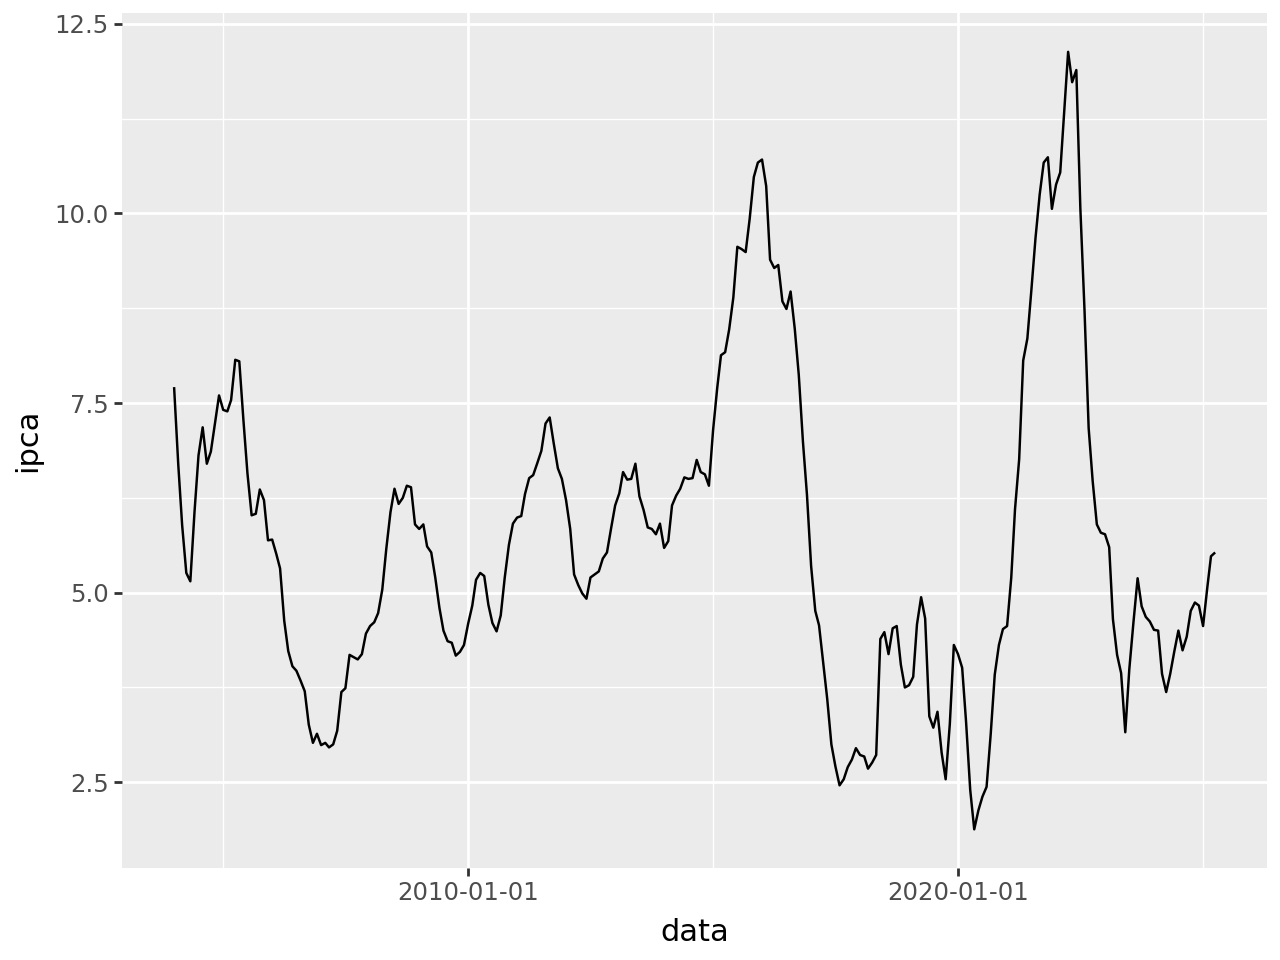

In [10]:
# Gráfico de linha do IPCA ao longo do tempo
(
    p9.ggplot(dados_tratados_ipca) +
    p9.aes(x='data', y='ipca') +
    p9.geom_line()
)

### Quais foram os pontos de máximo e mínimo no período para a inflação no Brasil?

In [12]:
# Filtro: seleciona as linhas com o maior e o menor valor de IPCA
dados_tratados_ipca.query("ipca == ipca.max() or ipca == ipca.min()")

,data,ipca
486,2020-05-01,1.88
509,2022-04-01,12.13


In [13]:
# Ordena os dados por IPCA e exibe apenas a menor e a maior linha
dados_tratados_ipca.sort_values(by='ipca').iloc[[0, -1]]

,data,ipca
486,2020-05-01,1.88
509,2022-04-01,12.13


### Qual o valor médio da inflação do Brasil e como é a distribuição de seus valores?

In [15]:
# Estatísticas descritivas da variável IPCA
dados_tratados_ipca.ipca.describe()

,ipca
count,256.000000
mean,5.703125
std,2.100745
min,1.880000
25%,4.237500
50%,5.465000
75%,6.590000
max,12.130000


/usr/local/lib/python3.11/dist-packages/plotnine/stats/stat_bin.py:109: PlotnineWarning: 'stat_bin()' using 'bins = 14'. Pick better value with 'binwidth'.


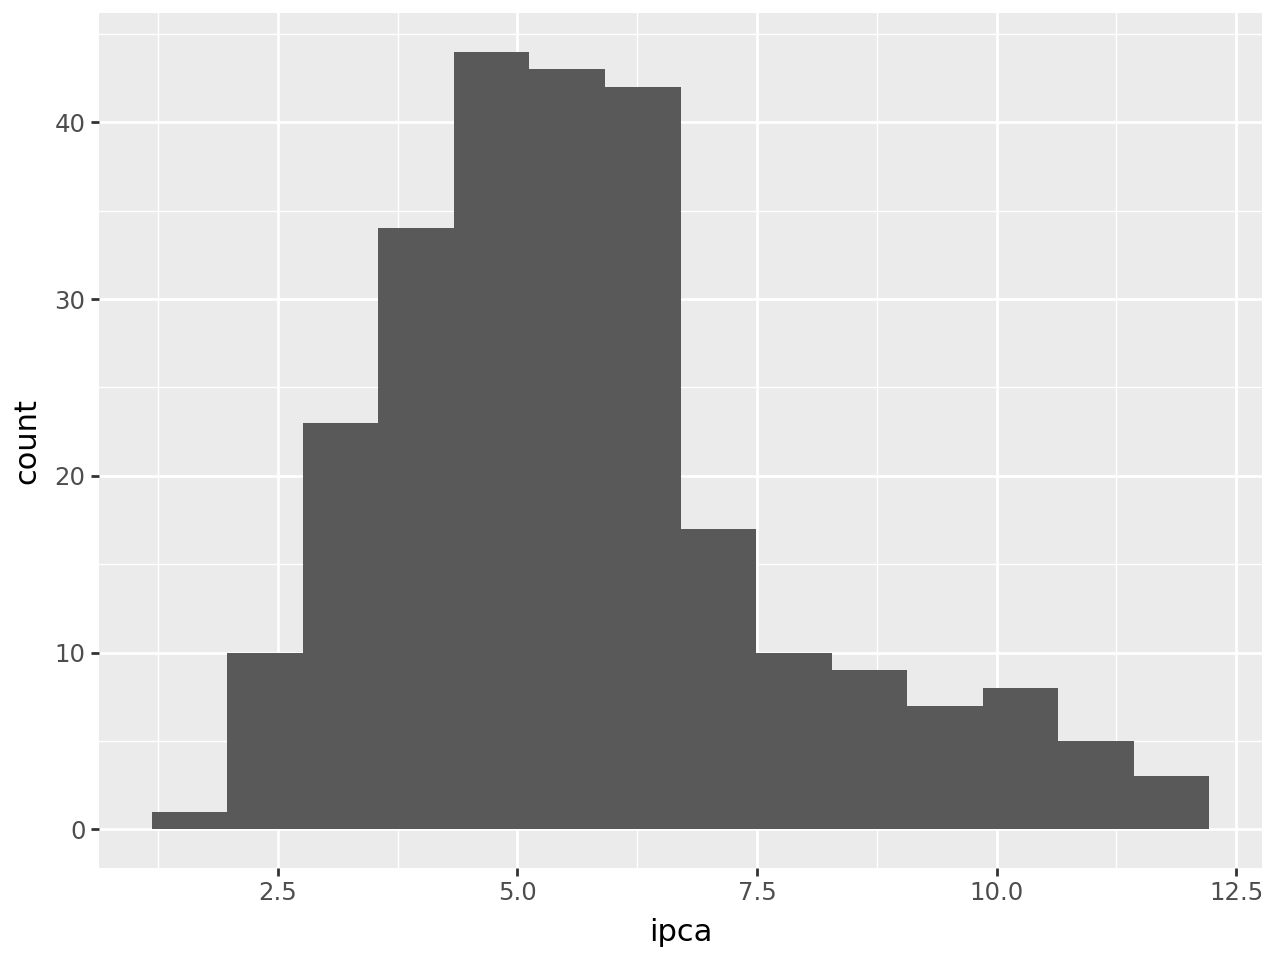

In [16]:
# Histograma da distribuição do IPCA
(
    p9.ggplot(dados_tratados_ipca) +
    p9.aes(x='ipca') +
    p9.geom_histogram()
)

### O que afeta a inflação? Com qual variável ela se relaciona?

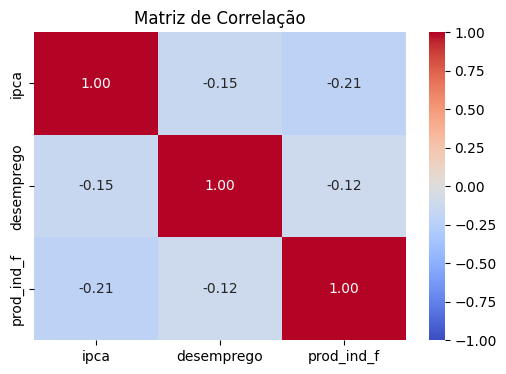

In [19]:
# Calcula correlação
correlacao = dados_cruzados[['ipca', 'desemprego', 'prod_ind_f']].corr()

# Exibe com seaborn
plt.figure(figsize=(6, 4))
sns.heatmap(
    correlacao,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1
)
plt.title("Matriz de Correlação")
plt.show()

In [20]:
# Define variáveis
X = dados_cruzados[['desemprego', 'prod_ind_f']]
X = sm.add_constant(X)  # Adiciona intercepto
y = dados_cruzados['ipca']

# Ajusta modelo
modelo = sm.OLS(y, X).fit()

# Mostra sumário padrão
print(modelo.summary())

# Sumário formatado
resumo_formatado = modelo.summary2().tables[1]
resumo_formatado


                            OLS Regression Results                            
Dep. Variable:                   ipca   R-squared:                       0.078
Model:                            OLS   Adj. R-squared:                  0.066
Method:                 Least Squares   F-statistic:                     6.517
Date:                Sun, 08 Jun 2025   Prob (F-statistic):            0.00192
Time:                        14:55:16   Log-Likelihood:                -359.52
No. Observations:                 158   AIC:                             725.0
Df Residuals:                     155   BIC:                             734.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.3467      0.730     10.062      0.0

,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
const,7.346694,0.730146,10.061955,1.212726e-18,5.904373,8.789014
desemprego,-0.166162,0.071223,-2.332993,2.093379e-02,-0.306854,-0.025470
prod_ind_f,-0.153995,0.051207,-3.007304,3.076232e-03,-0.255149,-0.052841


In [21]:
# Modelo de regressão com fórmula
modelo = smf.ols("ipca ~ desemprego + prod_ind_f", data=dados_cruzados).fit()

# Exibe sumário
print(modelo.summary())


                            OLS Regression Results                            
Dep. Variable:                   ipca   R-squared:                       0.078
Model:                            OLS   Adj. R-squared:                  0.066
Method:                 Least Squares   F-statistic:                     6.517
Date:                Sun, 08 Jun 2025   Prob (F-statistic):            0.00192
Time:                        14:55:42   Log-Likelihood:                -359.52
No. Observations:                 158   AIC:                             725.0
Df Residuals:                     155   BIC:                             734.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.3467      0.730     10.062      0.0

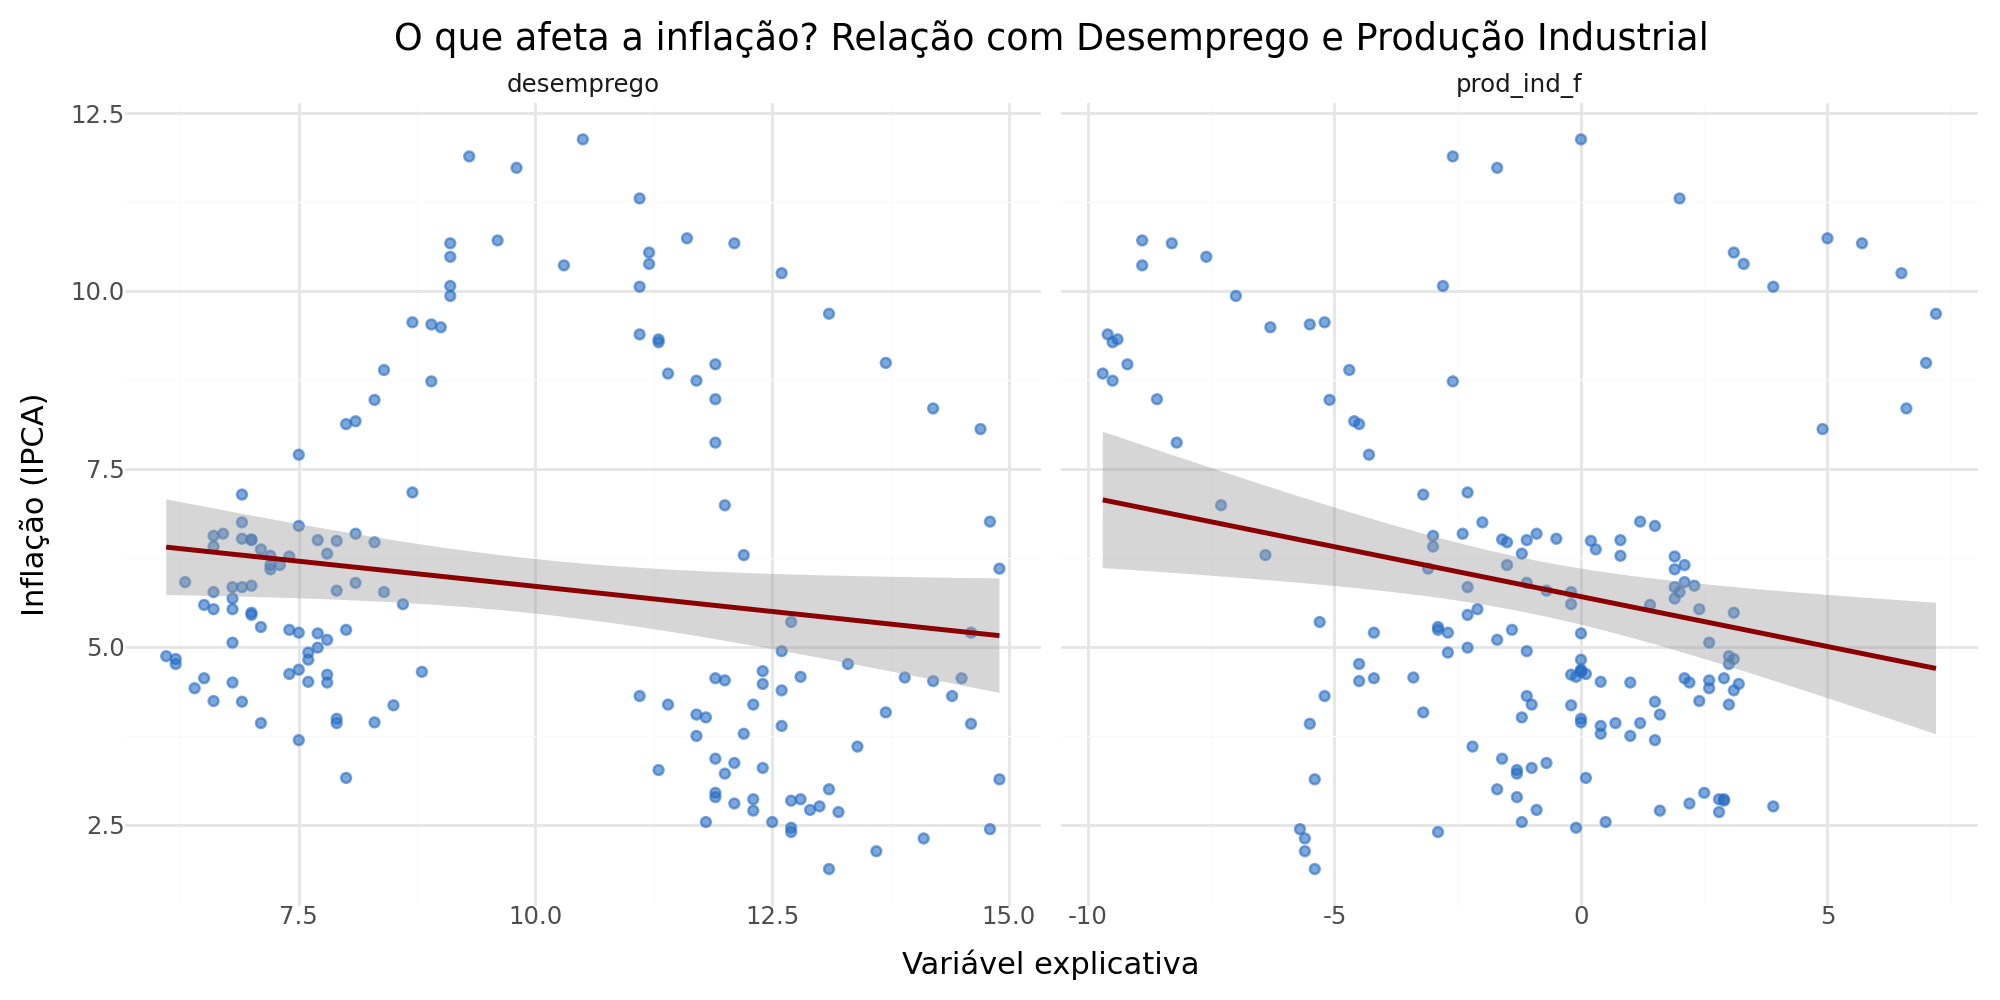

In [22]:
n_facetas = 2  # número de variáveis/facetas
grafico_facetas = (
    p9.ggplot(dados_long, p9.aes(x='valor', y='ipca')) +
    p9.geom_point(color="#276DC3", alpha=0.6) +
    p9.geom_smooth(method='lm', color="darkred") +
    p9.facet_wrap("~variavel", scales="free_x") +
    p9.labs(
        title="O que afeta a inflação? Relação com Desemprego e Produção Industrial",
        x="Variável explicativa",
        y="Inflação (IPCA)"
    ) +
    p9.theme_minimal() +
    p9.theme(figure_size=(5 * n_facetas, 5))  # Ajusta tamanho com base no número de facetas
)

grafico_facetas


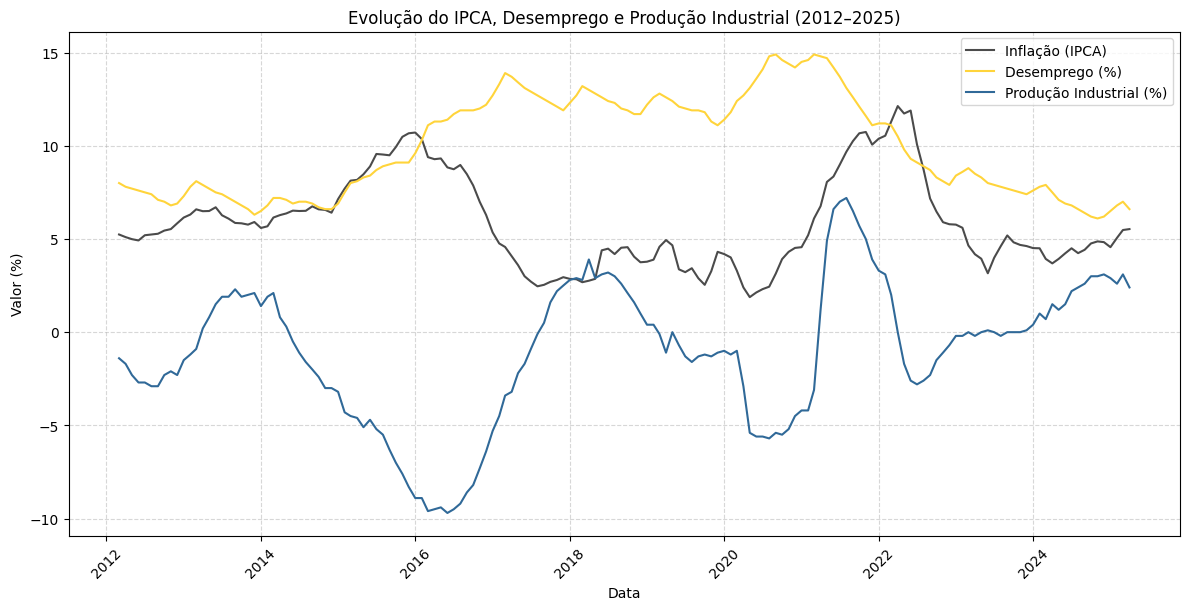

In [23]:
# Garantir que 'data' esteja como coluna
if 'data' not in dados_cruzados.columns:
    dados_cruzados = dados_cruzados.reset_index()

if 'data' not in dados_cruzados.columns:
    raise ValueError("A coluna 'data' não foi encontrada no DataFrame.")

# Criar gráfico de linha
plt.figure(figsize=(12, 6))

# Linha 1: IPCA – cinza escuro
plt.plot(dados_cruzados['data'], dados_cruzados['ipca'], label='Inflação (IPCA)', color='#4B4B4B')

# Linha 2: Desemprego – amarelo Python
plt.plot(dados_cruzados['data'], dados_cruzados['desemprego'], label='Desemprego (%)', color='#FFD43B')

# Linha 3: Produção Industrial – azul Python
plt.plot(dados_cruzados['data'], dados_cruzados['prod_ind_f'], label='Produção Industrial (%)', color='#306998')

# Customizações
plt.title("Evolução do IPCA, Desemprego e Produção Industrial (2012–2025)")
plt.xlabel("Data")
plt.ylabel("Valor (%)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()
